#任务：
#构造一个用于回归任务的全连接神经网络。我们会生成一个由非线性函数产生的合成数据集。数据集的样本数量为 1000,每个样本有 20 个特征，目标输出为一个标量。

#数据生成：
#生成 1000 个样本，每个样本的 20 维输入

#数据生成：
#生成 1000 个样本，每个样本的 20 维输入x来自标准正态分布。目标y按如下生成(这里的非线性函数仅作为一个示例，你可以自定义):
#y=sin($x_1$)+log(|$x_2$|+1)+0.5 $x_3^2$ - $x_4$+⋯+噪声

#网络结构要求：
#输入层： 20 个神经元（对应 20 维特征）。
#隐藏层 1: 50 个神经元，使用 ReLU 激活，并在其后添加 Dropout 层(丢弃率 0.5)。
#隐藏层 2: 30 个神经元，使用 ReLU 激活，并在其后添加 Dropout 层(丢弃率 0.5)。
#隐藏层 3: 20 个神经元，使用 ReLU 激活，并在其后添加 Dropout 层(丢弃率 0.5)。
#输出层： 1 个神经元，直接输出预测值（回归任务不需要激活）。

#训练要求：
#损失函数使用均方误差损失(MSELoss)。
#优化器使用 Adam,学习率设置为 0.001。
#训练一定的 epoch(例如 1000 或更多)，绘制训练过程中损失的变化曲线。
#另外，可以将数据划分为训练集和验证集，展示验证集上预测值与真实值的散点图，以直观评价模型效果。

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [60]:
class SimpleNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(20, 50)
    self.dropout1 = nn.Dropout(p=0.5)

    self.layer2 = nn.Linear(50, 30)
    self.dropout2 = nn.Dropout(p=0.5)

    self.layer3 = nn.Linear(30, 20)
    self.dropout3 = nn.Dropout(p=0.5)

    self.output = nn.Linear(20, 1)

  def forward(self, x):
    x = torch.relu(self.layer1(x))
    x = self.dropout1(x)

    x = torch.relu(self.layer2(x))
    x = self.dropout2(x)

    x = torch.relu(self.layer3(x))
    x = self.dropout3(x)

    x = self.output(x)
    return x

y=sin($x_1$)+log(|$x_2$|+1)+0.5 $x_3^2$ - $x_4$+⋯+噪声

epoch: 1 train_loss: 3.7897, val_loss: 3.4284 y_per: -21.1311% y_val: 1.0934, y_pred_val: -0.2310
epoch: 201 train_loss: 1.0069, val_loss: 0.5504 y_per: 80.1691% y_val: 1.0934, y_pred_val: 0.8765
epoch: 401 train_loss: 0.8161, val_loss: 0.3416 y_per: 80.1508% y_val: 1.0934, y_pred_val: 0.8763
epoch: 601 train_loss: 0.6427, val_loss: 0.2660 y_per: 85.5904% y_val: 1.0934, y_pred_val: 0.9358
epoch: 801 train_loss: 0.6368, val_loss: 0.2400 y_per: 88.1908% y_val: 1.0934, y_pred_val: 0.9643
epoch: 1001 train_loss: 0.5671, val_loss: 0.2376 y_per: 88.6981% y_val: 1.0934, y_pred_val: 0.9698
epoch: 1201 train_loss: 0.6026, val_loss: 0.2192 y_per: 92.3990% y_val: 1.0934, y_pred_val: 1.0103
epoch: 1401 train_loss: 0.5014, val_loss: 0.2090 y_per: 94.5134% y_val: 1.0934, y_pred_val: 1.0334
epoch: 1601 train_loss: 0.4627, val_loss: 0.2034 y_per: 94.8600% y_val: 1.0934, y_pred_val: 1.0372
epoch: 1801 train_loss: 0.4414, val_loss: 0.2042 y_per: 95.0004% y_val: 1.0934, y_pred_val: 1.0387
epoch: 2001 tra

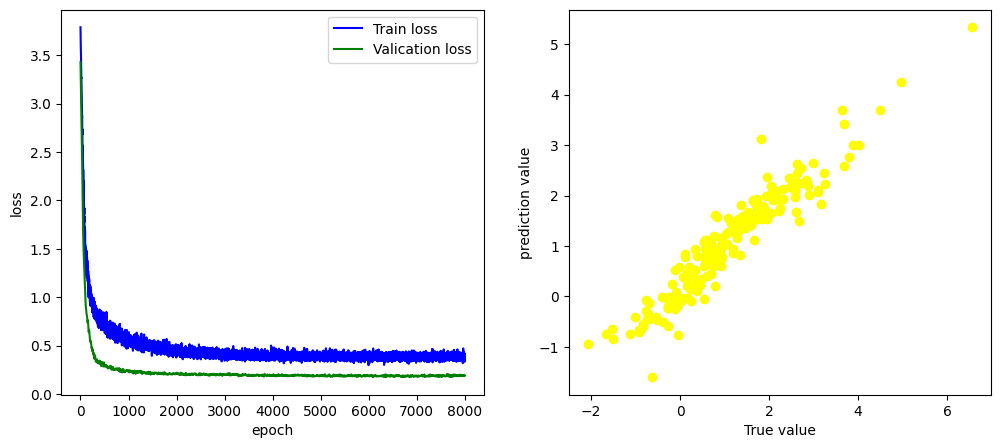

In [64]:
#初始化参数
sample_num = 1000
input_dim = 20

noise = 0.1 * torch.randn(sample_num, 1).to(device)

x = torch.randn(sample_num, input_dim).to(device)
y = (torch.sin(x[:,0:1])
  + torch.log(torch.abs(x[:,1:2]) + 1)
  + 0.5*(x[:,2:3]**2)
  - x[:,3:4]) + noise

rss_model = SimpleNN().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(rss_model.parameters(), lr=0.001)

losses_train = []
losses_val = []
epochs = 8000

train_num = int(0.8 * sample_num)
x_train = x[:train_num].to(device)
y_train = y[:train_num].to(device)
x_val = x[train_num:].to(device)
y_val = y[train_num:].to(device)

for epoch in range(epochs):
  rss_model.train()
  y_pred_train = rss_model(x_train)

  loss_train = criterion(y_pred_train, y_train)
  losses_train.append(loss_train.item())

  optimizer.zero_grad()
  loss_train.backward()
  optimizer.step()

  rss_model.eval()
  with torch.no_grad():
    y_pred_val = rss_model(x_val)
    loss_val = criterion(y_pred_val, y_val)
    losses_val.append(loss_val.item())

  if epoch%200 ==0:
    print(f"epoch: {epoch + 1}",
      f"train_loss: {loss_train.item():.4f}, val_loss: {loss_val.item():.4f}",
      f"y_per: {(y_pred_val.flatten().mean()/y_val.flatten().mean()*100):.4f}% y_val: {y_val.flatten().mean():.4f}, y_pred_val: {y_pred_val.flatten().mean():.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(range(epochs), losses_train, label="Train loss", color="blue")
plt.plot(range(epochs), losses_val, label="Valication loss", color="green")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

rss_model.eval()
with torch.no_grad():
  y_pred_val = rss_model(x_val).cpu().numpy()
  y_val_np = y_val.cpu().numpy()

plt.subplot(1,2,2)
plt.scatter(y_val_np, y_pred_val, color="yellow")
plt.xlabel("True value")
plt.ylabel("prediction value")

plt.show()

Epoch 1/1000 -- Train Loss: 2.9243  Val Loss: 2.4624
Epoch 51/1000 -- Train Loss: 1.9184  Val Loss: 1.4303
Epoch 101/1000 -- Train Loss: 1.4394  Val Loss: 0.8684
Epoch 151/1000 -- Train Loss: 1.1238  Val Loss: 0.5989
Epoch 201/1000 -- Train Loss: 0.8781  Val Loss: 0.4305
Epoch 251/1000 -- Train Loss: 0.8399  Val Loss: 0.3623
Epoch 301/1000 -- Train Loss: 0.7921  Val Loss: 0.3081
Epoch 351/1000 -- Train Loss: 0.7472  Val Loss: 0.2991
Epoch 401/1000 -- Train Loss: 0.6770  Val Loss: 0.2804
Epoch 451/1000 -- Train Loss: 0.5940  Val Loss: 0.2677
Epoch 501/1000 -- Train Loss: 0.5989  Val Loss: 0.2507
Epoch 551/1000 -- Train Loss: 0.6400  Val Loss: 0.2342
Epoch 601/1000 -- Train Loss: 0.6806  Val Loss: 0.2455
Epoch 651/1000 -- Train Loss: 0.5343  Val Loss: 0.2273
Epoch 701/1000 -- Train Loss: 0.5557  Val Loss: 0.2293
Epoch 751/1000 -- Train Loss: 0.4808  Val Loss: 0.2081
Epoch 801/1000 -- Train Loss: 0.4927  Val Loss: 0.2105
Epoch 851/1000 -- Train Loss: 0.5203  Val Loss: 0.2103
Epoch 901/100

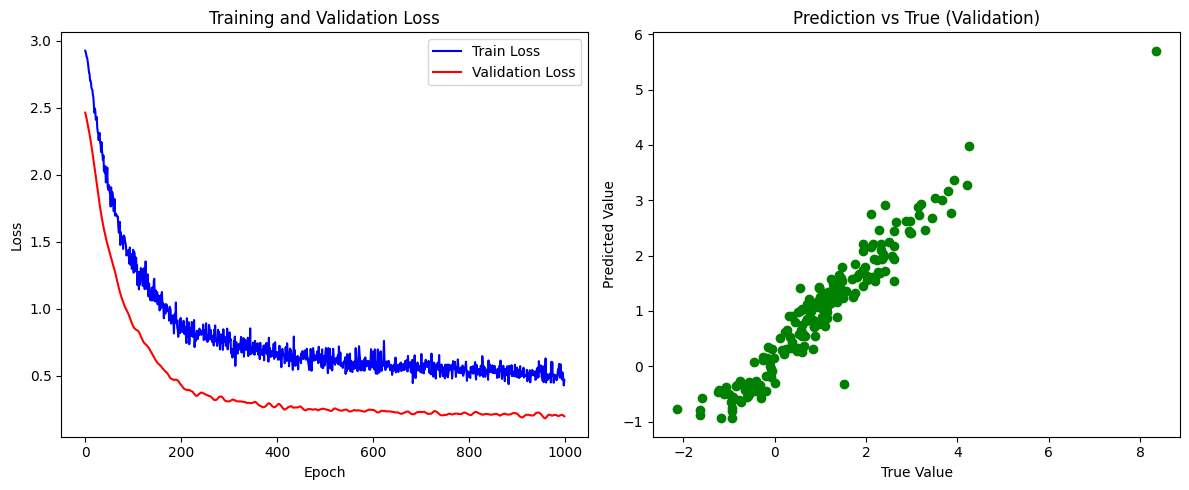

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子便于复现
torch.manual_seed(42)
np.random.seed(42)

# ==========================
# 1. 数据生成
# ==========================
# 样本数量和特征维度
num_samples = 1000
input_dim = 20

# 生成输入数据，服从标准正态分布
X = torch.randn(num_samples, input_dim)

# 模拟一个复杂的非线性函数来生成目标输出 y（这里只使用前4个特征来构造示例函数）
# 你也可以尝试加入更多维度的组合
noise = 0.1 * torch.randn(num_samples, 1)  # 添加少量高斯噪声
y = (
    torch.sin(X[:, 0:1]) +
    torch.log(torch.abs(X[:, 1:2]) + 1) +
    0.5 * (X[:, 2:3] ** 2) -
    X[:, 3:4]
) + noise

# 划分训练集和验证集（例如 80%训练，20%验证）
train_size = int(0.8 * num_samples)
val_size = num_samples - train_size

X_train = X[:train_size].to(torch.float32)
y_train = y[:train_size].to(torch.float32)
X_val = X[train_size:].to(torch.float32)
y_val = y[train_size:].to(torch.float32)

# ==========================
# 2. 定义网络模型
# ==========================
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.dropout1 = nn.Dropout(p=0.5)
        self.layer2 = nn.Linear(50, 30)
        self.dropout2 = nn.Dropout(p=0.5)
        self.layer3 = nn.Linear(30, 20)
        self.dropout3 = nn.Dropout(p=0.5)
        self.output_layer = nn.Linear(20, 1)

    def forward(self, x):
        # 隐藏层1：Linear -> ReLU -> Dropout
        x = torch.relu(self.layer1(x))
        x = self.dropout1(x)
        # 隐藏层2：Linear -> ReLU -> Dropout
        x = torch.relu(self.layer2(x))
        x = self.dropout2(x)
        # 隐藏层3：Linear -> ReLU -> Dropout
        x = torch.relu(self.layer3(x))
        x = self.dropout3(x)
        # 输出层，不使用激活函数
        x = self.output_layer(x)
        return x

# 实例化模型并将其移到对应设备（这里使用 CPU 或 GPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RegressionNN().to(device)

# ==========================
# 3. 定义损失函数与优化器
# ==========================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================
# 4. 训练模型
# ==========================
epochs = 1000
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # 前向传播与训练损失计算
    y_pred_train = model(X_train.to(device))
    loss_train = criterion(y_pred_train, y_train.to(device))

    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    # 验证阶段
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val.to(device))
        loss_val = criterion(y_pred_val, y_val.to(device))
        val_losses.append(loss_val.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} -- Train Loss: {loss_train.item():.4f}  Val Loss: {loss_val.item():.4f}")

# ==========================
# 5. 绘制损失曲线 & 展示预测结果（验证集）
# ==========================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# 在验证集上绘制散点图比较预测值与真实值
model.eval()
with torch.no_grad():
    y_pred_val = model(X_val.to(device)).cpu().numpy()
    y_val_np = y_val.cpu().numpy()

plt.subplot(1, 2, 2)
plt.scatter(y_val_np, y_pred_val, color="green")
plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.title("Prediction vs True (Validation)")

plt.tight_layout()
plt.show()
